In [2]:
# Importing necessary modules and libraries
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [4]:
X,y = make_regression(n_samples=100, n_features = 1,n_informative=1,n_targets=1,random_state=13,noise=20)

In [ ]:
# This make_regresssion already forms X in dataframe format and y in Series foramt which we need inside LR.fit()
print(X.shape)
print(y.shape)

(100, 1)
(100,)


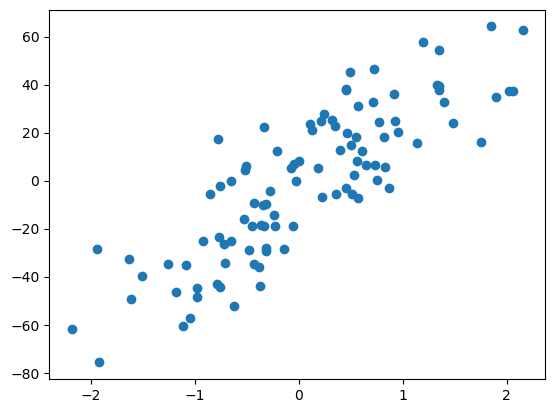

In [ ]:
# Plotting the X and y points
plt.scatter(X,y)

In [9]:
# Let us split the data into Training and testing datasets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=2)

In [10]:
# Let us create and fit the LinearRegression Model
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)

In [ ]:
# Finding the value of weightage(m) and intercept (b) using model
print(lr.coef_[0])
print(lr.intercept_)

28.125973315135614
-2.2710144261783825


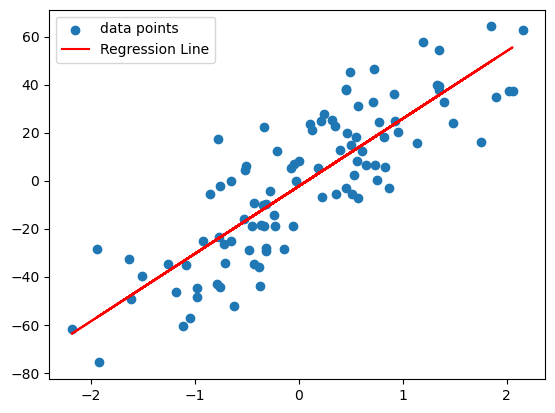

In [15]:
# Plotting the Scatter and Regression line 
plt.scatter(X,y,label='data points')
plt.plot(X_train.ravel(),lr.predict(X_train),color='red',label='Regression Line')
plt.legend()
plt.show()

In [65]:
# Let us Compute the Gradient Descent 
# For now Let us keep m constant and just vary b!!
m = 28.125973315135614 # constant m just vary b to check how it gradient descent works
b = 100 # Starting random value
learning_rate = 0.01

In [66]:
# First Iteration 
y_pred = ((m*X_train) + b).reshape(80) # here b = 100

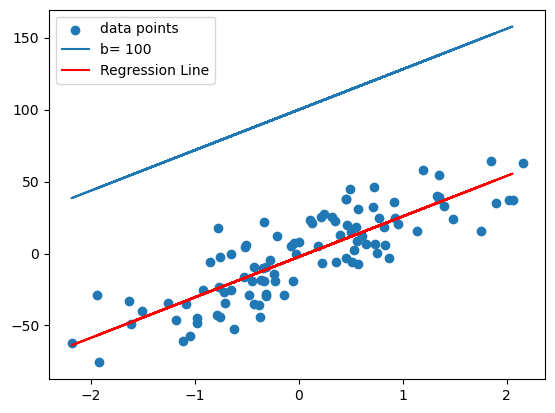

In [67]:
# First Plot
plt.scatter(X,y,label='data points')
plt.plot(X_train.ravel(),y_pred,label=f'b= {b}')
plt.plot(X_train.ravel(),lr.predict(X_train),color='red',label='Regression Line')
plt.legend()
plt.show()

In [68]:
# Iteration 2
# Derviatve of Loss function wrt b, we get slope_b
slope_b = -2*np.sum(y_train - m*X_train.ravel() - b) 
b = b - learning_rate*slope_b
y_pred_1 = ((m*X_train) + b).reshape(80)

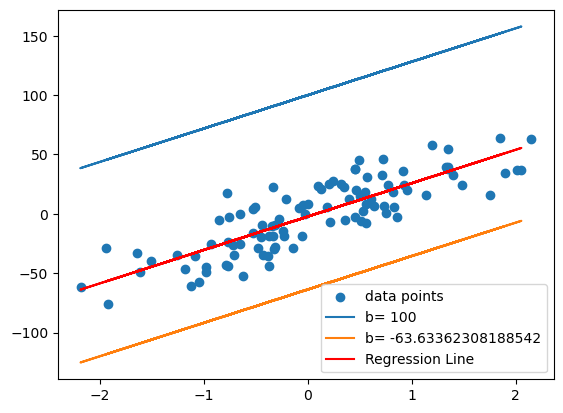

In [69]:
# Second Plot
plt.scatter(X,y,label='data points')
plt.plot(X_train.ravel(),y_pred,label=f'b= 100')
plt.plot(X_train.ravel(),y_pred_1,label=f'b= {b}')
plt.plot(X_train.ravel(),lr.predict(X_train),color='red',label='Regression Line')
plt.legend()
plt.show()

In [70]:
# Iteration 3
slope_b = -2*np.sum(y_train - m*X_train.ravel() - b) 
b = b - learning_rate*slope_b
y_pred_2 = ((m*X_train) + b).reshape(80)

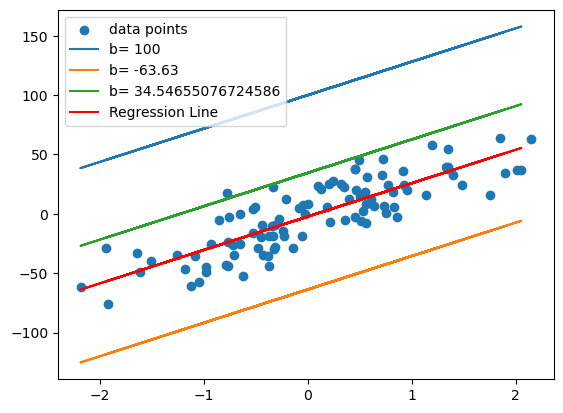

In [71]:
# Third Plot
plt.scatter(X,y,label='data points')
plt.plot(X_train.ravel(),y_pred,label=f'b= 100')
plt.plot(X_train.ravel(),y_pred_1,label=f'b= -63.63')
plt.plot(X_train.ravel(),y_pred_2,label=f'b= {b}')
plt.plot(X_train.ravel(),lr.predict(X_train),color='red',label='Regression Line')
plt.legend()
plt.show()

`This is how we converge to our Regression line -> correct values of m and b iteratively`

#### Iterative Process To find m and b in one code

In [73]:
# Slope_m = -2*np.sum(y_train - m*X_train - b)*X_train

60.27769775339432 -57.302698507671664
15.943215630608357 28.142586659963627
31.967400341412755 -19.53194744108837
27.536326676964357 7.774256016008515
27.617166999392882 -8.250394779364534
28.873877543827213 1.3578448164797354
27.444782295719644 -4.508936260049276
28.65991815386586 -0.8730611308175229
27.736312129555216 -3.1530545299519472
28.399144066949894 -1.7102142379380902
27.939131472742396 -2.6296308831862847
28.25174602672453 -2.040703855975817
28.0422081956364 -2.419392737971157
28.18135527502057 -2.1751995473044223
28.089542395713373 -2.332991220929246
28.14985281335964 -2.230876176148515
28.110360313487963 -2.297032447155567
28.136163217253113 -2.254138416736096
28.119331316325642 -2.281965768778436
28.130298758795416 -2.263905387407247
28.123158317441852 -2.275630361011008
28.127804453890693 -2.268016752433365
28.124782572816358 -2.2729614164339287
28.126747436188616 -2.2697497404296123
28.125470134259007 -2.271835968391689
28.12630034303717 -2.2704807256761272
28.125760791

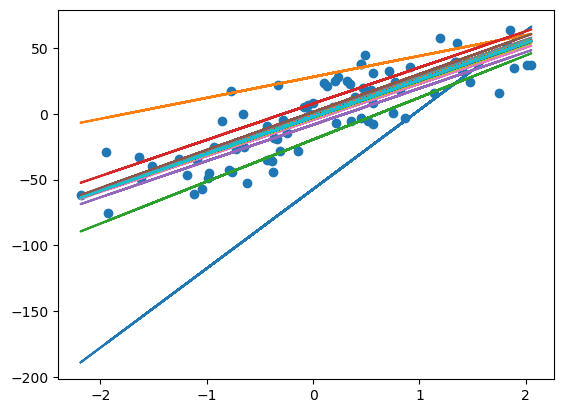

In [94]:
# Here both m and b will vary and the optimum values will be found iteratively
m = -50
b = 100
learning_rate = 0.01
epochs = 100
for i in range(epochs):
    slope_m = -2*np.sum(((y_train - m*X_train.ravel()) - b)*X_train.ravel())
    slope_b = -2*np.sum((y_train - m*X_train.ravel()) - b)
    m = m - learning_rate*slope_m
    b = b - learning_rate*slope_b
    y_pred = m*X_train.ravel() + b
    print(m,b)
    plt.plot(X_train, y_pred)
plt.scatter(X_train,y_train)
plt.show()